## Q4 Findings: Genre Preferences by Region

**Two Distinct Market Segments Emerge:**

**Segment 1 — Western markets + Other (NA, EU, Other):**
- Consistent preference ordering: Action → Sports → Shooter dominant
- Regional shares within 1-3 percentage points of each other
- These three regions behave analytically as a single broad segment

**Segment 2 — Japan:**
- Structurally distinct preference profile
- Role-Playing dominates at 27.3% of Japanese sales (vs 7-8% in Western markets)
- Shooter is minor at 3.0% (vs 12.9-13.3% in Western markets)
- Action and Sports have smaller share than in Western markets

**One striking absolute-value finding:**
Role-Playing in Japan ($352M) exceeds Role-Playing in North America 
($327M) — the only genre where Japan surpasses NA in absolute terms 
despite being a smaller overall market.

**Business implications:**
Genre portfolios must be regionally weighted:
- Shooter franchises optimised for Western markets face 4× smaller 
  addressable share in Japan
- Japanese RPG conventions have structural ceiling in Western markets 
  (7% share vs 27% share)
- Assuming global uniformity would misallocate marketing spend and 
  distribution priority

**Methodological notes:**
- Regional shares computed as % of each region's own total sales
- Top 6 genres by global sales selected for readability (accounts for 
  ~76% of NA sales, similar shares elsewhere)
- Alternative view (absolute values) would emphasise NA market size 
  rather than preference patterns

**Follow-up questions this raises:**
- How do publisher strategies map to these regional preferences? (Q5)
- Does the RPG-Japan pattern hold across all eras, or is it a specific 
  vintage effect?
- Are there platform-level differences that explain the segmentation?

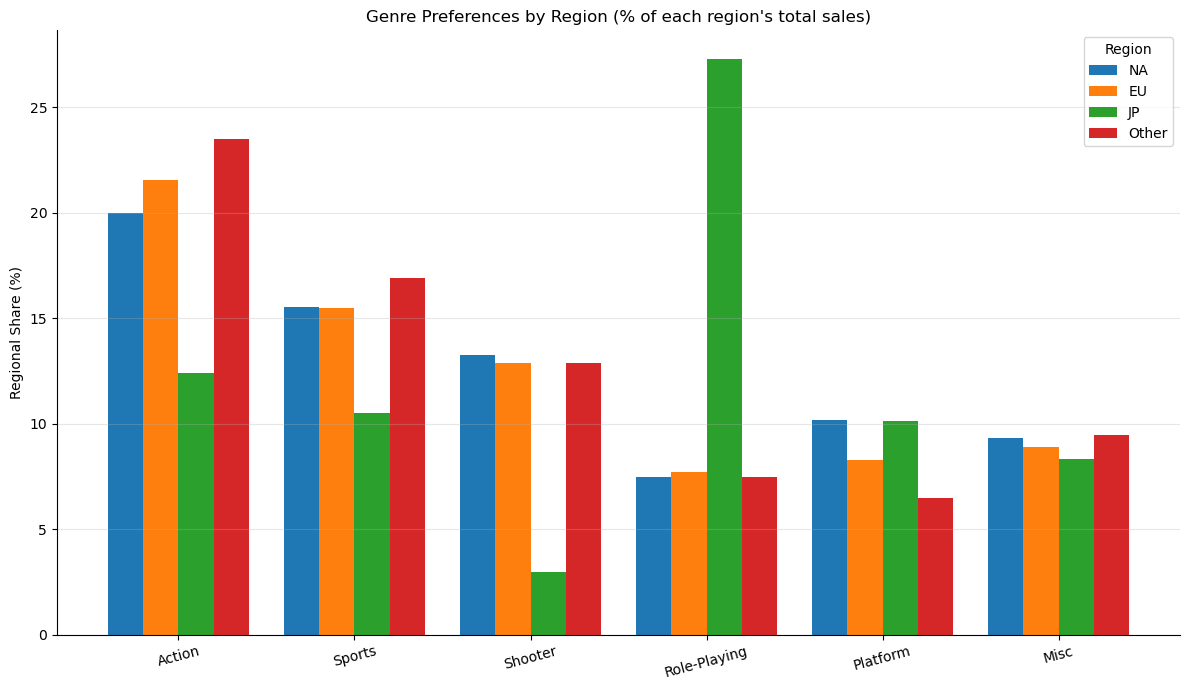

In [3]:
# Step 3 - Visualise Pattern Identified in relation to Genre Preferences by Region.

import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
genres = genre_region_share_top.index
regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

n_genres = len(genres)
n_regions = len(regions)

bar_width = 0.2
x_positions = np.arange(n_genres)

fig, ax = plt.subplots(figsize=(12, 7))

# 2. Plot grouped bars
for i, region in enumerate(regions):
    offset = (i - n_regions/2 + 0.5) * bar_width
    ax.bar(
        x_positions + offset,
        genre_region_share_top[region].values,
        width=bar_width,
        label=region.replace("_Sales", "")
    )

# 3. Axis labels & title
ax.set_xticks(x_positions)
ax.set_xticklabels(genres, rotation=15)

ax.set_ylabel("Regional Share (%)")
ax.set_title("Genre Preferences by Region (% of each region's total sales)")

# 4. Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Region")

plt.tight_layout()

# 5. Save output
plt.savefig("outputs/q4_genre_by_region.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
# Step 2 - Genre Preferences by Region.

# 1. Total regional sales per genre (absolute values)
genre_region_sales = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()
)

# 2. Total sales per region (for share calculation)
region_totals = genre_region_sales.sum(axis=0)

# 3. Regional shares per genre (percentage of each region’s total)
genre_region_share = genre_region_sales.div(region_totals, axis=1) * 100

# 4. Top 6 genres by global sales (increase readability)
genre_global_sales = df.groupby("Genre")["Global_Sales"].sum()
top_genres = (
    genre_global_sales
    .sort_values(ascending=False)
    .head(6)
    .index
)

# 5. Filter both absolute and share tables to top genres
genre_region_sales_top = genre_region_sales.loc[top_genres]
genre_region_share_top = genre_region_share.loc[top_genres]

genre_region_sales_top, genre_region_share_top


(              NA_Sales  EU_Sales  JP_Sales  Other_Sales
 Genre                                                  
 Action          877.83    525.00    159.95       187.38
 Sports          683.35    376.85    135.37       134.97
 Shooter         582.60    313.27     38.28       102.69
 Role-Playing    327.28    188.06    352.31        59.61
 Platform        447.05    201.63    130.77        51.59
 Misc            410.24    215.98    107.76        75.32,
                NA_Sales   EU_Sales   JP_Sales  Other_Sales
 Genre                                                     
 Action        19.982700  21.568281  12.389429    23.488562
 Sports        15.555606  15.481918  10.485508    16.918834
 Shooter       13.262159  12.869896   2.965097    12.872454
 Role-Playing   7.450119   7.725964  27.289275     7.472266
 Platform      10.176533   8.283452  10.129200     6.466938
 Misc           9.338599   8.872985   8.346889     9.441554)

In [1]:
# Step 1 - Load & Inspect Dataset.

import pandas as pd
from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "vgsales.csv")
df.columns = df.columns.str.strip()

# Standard inspection
df.shape
df.columns.tolist()
df.dtypes
df.head()
df["Publisher"].nunique()
df["Publisher"].value_counts().head(10)
df["Year"].min(), df["Year"].max()
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64